In [1]:
import numpy as np
import tensorflow as tf
import random
import os
import pandas as pd
from sklearn.model_selection import train_test_split

SEQ_LEN = 10
TARGET_COL = "label"

CLASSES = ["air", "cinnamon", "rosemary"]
NUM_CLASSES = len(CLASSES)

FEATURE_COLS = [
    "humidity_z",
    "log_ratio",
]

In [2]:
# %%
def load_dataset(base_dir: str) -> pd.DataFrame:
    dfs = []
    session_id = 0

    for class_folder in os.listdir(base_dir):
        if class_folder not in CLASSES: continue

        folder_path = os.path.join(base_dir, class_folder)

        if not os.path.isdir(folder_path):
            continue

        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue

            file_path = os.path.join(folder_path, file)
            df = pd.read_csv(file_path)

            df["session_id"] = session_id

            df["id"] = df.apply(
                lambda x: f"{session_id}_{int(x['sensor_index'])}_{int(x['fingerprint_index'])}",
                axis=1,
            )

            dfs.append(df)
            session_id += 1

    if not dfs:
        raise ValueError("No CSVW files found.")

    return pd.concat(dfs, ignore_index=True)


data = load_dataset("../data/new-dataset")

# Keep only stable rows
data = data[data["label"].str.endswith("Stable")].copy()

# Convert labels
data["label"] = data["label"].replace({"baselineStable": "air"})
data["label"] = data["label"].str.replace("Stable", "", regex=False)

print("Sessions:", data["session_id"].nunique())

Sessions: 11


In [3]:
def compute_baseline(df: pd.DataFrame) -> pd.DataFrame:
    baseline = (
        df[df["label"] == "air"]
        .groupby(["session_id", "sensor_index", "position"])["gas_resistance"]
        .mean()
        .rename("R_base")
        .reset_index()
    )

    df = df.merge(
        baseline,
        on=["session_id", "sensor_index", "position"],
        how="left"
    )

    if df["R_base"].isna().any():
        missing = df[df["R_base"].isna()]["session_id"].unique()
        raise ValueError(f"Missing air baseline in sessions: {missing}")

    return df

data = compute_baseline(data)
data.head()

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,session_id,id,R_base
0,3,31,1,150,180,33.18,1033.76,37.09,7156148,air,0,0_3_31,7.090028e+06
1,1,30,7,380,140,34.07,1029.70,27.09,88306,air,0,0_1_30,8.718150e+04
2,8,29,7,380,140,32.91,1010.61,25.76,69245,air,0,0_8_29,6.875067e+04
3,7,32,3,250,150,33.37,1063.82,32.17,253905,air,0,0_7_32,2.499395e+05
4,5,29,7,380,140,32.70,1112.03,34.55,91527,air,0,0_5_29,9.114756e+04


In [4]:
from sklearn.preprocessing import LabelEncoder

sessions = data["session_id"].unique()

train_sessions, temp_sessions = train_test_split(
    sessions,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_sessions, test_sessions = train_test_split(
    temp_sessions,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

train_data = data[data["session_id"].isin(train_sessions)].copy()
val_data   = data[data["session_id"].isin(val_sessions)].copy()
test_data  = data[data["session_id"].isin(test_sessions)].copy()

label_encoder = LabelEncoder()

train_data["label_enc"] = label_encoder.fit_transform(train_data[TARGET_COL])
val_data["label_enc"] = label_encoder.transform(val_data[TARGET_COL])
test_data["label_enc"] = label_encoder.transform(test_data[TARGET_COL])

print("Train sessions:", len(train_sessions))
print("Val sessions  :", len(val_sessions))
print("Test sessions :", len(test_sessions))

Train sessions: 7
Val sessions  : 2
Test sessions : 2


In [5]:
def print_split_classes(name, df):
    classes = sorted(df[TARGET_COL].unique())
    print(f"\n{name} classes ({len(classes)}): {classes}")

print_split_classes("Train", train_data)
print_split_classes("Validation", val_data)
print_split_classes("Test", test_data)


Train classes (3): ['air', 'cinnamon', 'rosemary']

Validation classes (3): ['air', 'cinnamon', 'rosemary']

Test classes (3): ['air', 'cinnamon', 'rosemary']


In [6]:
train_data["log_ratio"] = np.log(
    train_data["gas_resistance"] / train_data["R_base"]
)

val_data["log_ratio"] = np.log(
    val_data["gas_resistance"] / val_data["R_base"]
)

test_data["log_ratio"] = np.log(
    test_data["gas_resistance"] / test_data["R_base"]
)

In [7]:
env_cols = ["humidity"]

for col in env_cols:
    mean = train_data.groupby("sensor_index")[col].mean()
    std  = train_data.groupby("sensor_index")[col].std()

    train_data[f"{col}_z"] = (
        train_data[col] - train_data["sensor_index"].map(mean)
    ) / train_data["sensor_index"].map(std)

    val_data[f"{col}_z"] = (
        val_data[col] - val_data["sensor_index"].map(mean)
    ) / val_data["sensor_index"].map(std)

    test_data[f"{col}_z"] = (
        test_data[col] - test_data["sensor_index"].map(mean)
    ) / test_data["sensor_index"].map(std)

In [8]:
def keep_complete(df):
    valid_ids = (
        df.groupby("id")
          .size()
          .loc[lambda x: x == SEQ_LEN]
          .index
    )
    return df[df["id"].isin(valid_ids)]

train_data = keep_complete(train_data)
val_data = keep_complete(val_data)
test_data  = keep_complete(test_data)

print("Train fingerprints:", train_data["id"].nunique())
print("Val fingerprints:", val_data["id"].nunique())
print("Test fingerprints :", test_data["id"].nunique())

Train fingerprints: 1609
Val fingerprints: 376
Test fingerprints : 326


In [9]:
train_data

,sensor_index,fingerprint_index,position,plate_temperature,heater_duration,temperature,pressure,humidity,gas_resistance,label,session_id,id,R_base,label_enc,log_ratio,humidity_z
1741,8,110,0,100,200,33.81,1010.59,25.01,16956274,air,1,1_8_110,1.680677e+07,0,0.008856,-0.121767
1749,8,110,1,150,180,33.80,1010.58,25.07,3208146,air,1,1_8_110,3.198318e+06,0,0.003068,-0.108191
1752,5,110,0,100,200,33.03,1112.01,34.60,22148022,air,1,1_5_110,2.235679e+07,0,-0.009382,-0.231157
1757,8,110,2,200,160,33.79,1010.58,25.03,689330,air,1,1_8_110,6.860543e+05,0,0.004763,-0.117241
1759,4,117,0,100,200,32.12,1103.58,35.97,31200190,air,1,1_4_117,3.094562e+07,0,0.008193,-0.321768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25066,4,105,9,450,140,33.18,1098.54,32.79,107450,rosemary,8,8_4_105,1.202758e+05,2,-0.112762,-0.715822
25068,5,99,7,380,140,35.35,1107.15,30.82,62272,rosemary,8,8_5_99,8.399792e+04,2,-0.299280,-0.857530
25070,2,105,9,450,140,33.50,1101.48,34.30,113904,rosemary,8,8_2_105,1.190957e+05,2,-0.044571,-0.734717
25076,5,99,8,415,140,35.35,1107.15,30.83,69755,rosemary,8,8_5_99,9.584383e+04,2,-0.317731,-0.855873


In [10]:
import numpy as np

def create_sequences_grouped(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    seq_len: int
):
    X, y = [], []
    grouped = df.groupby("id")
    num_skipped = 0
    for _id, group in grouped:
        group = group.sort_values("position")
        data = group[feature_cols].values

        if len(data) == seq_len:
            X.append(data)
            y.append(int(group[target_col].iloc[0]))
        else:
            num_skipped += 1
    print("Number of sequences skipped: ", num_skipped)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)


X_train, y_train = create_sequences_grouped(train_data, FEATURE_COLS, 'label_enc', SEQ_LEN)
X_val, y_val = create_sequences_grouped(val_data, FEATURE_COLS, 'label_enc', SEQ_LEN)
X_test, y_test = create_sequences_grouped(test_data, FEATURE_COLS, 'label_enc', SEQ_LEN)

Number of sequences skipped:  0
Number of sequences skipped:  0
Number of sequences skipped:  0


In [11]:
from keras.models import Sequential
from keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D

model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS))),

    Conv1D(16, kernel_size=3, activation='relu'),
    Conv1D(16, kernel_size=3, activation='relu'),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 8, 16)          │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,539 (6.01 KB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    shuffle=True
)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5904 - loss: 1.0240 - val_accuracy: 0.7527 - val_loss: 0.9057
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6880 - loss: 0.8980 - val_accuracy: 0.8298 - val_loss: 0.6272
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7638 - loss: 0.7377 - val_accuracy: 0.9654 - val_loss: 0.3579
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8086 - loss: 0.5894 - val_accuracy: 0.9761 - val_loss: 0.2024
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8341 - loss: 0.5002 - val_accuracy: 0.9761 - val_loss: 0.1461
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8527 - loss: 0.4448 - val_accuracy: 0.9734 - val_loss: 0.1235
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8602 - loss: 0.4084 - val_accuracy: 0.9761 - val_loss: 0.1208
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8682 - loss: 0.3846 - val_accuracy: 0.9787 - val_loss:

In [13]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test, y_pred, labels=np.unique(y_test),
                            target_names=label_encoder.inverse_transform(np.unique(y_test))))


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Overall Test Accuracy: 0.9938650306748467
air                  : 1.000  (n_test=125)
cinnamon             : 0.974  (n_test=78)
rosemary             : 1.000  (n_test=123)

Classification Report (only shows classes present in y_test):
              precision    recall  f1-score   support

         air       0.98      1.00      0.99       125
    cinnamon       1.00      0.97      0.99        78
    rosemary       1.00      1.00      1.00       123

    accuracy                           0.99       326
   macro avg       0.99      0.99      0.99       326
weighted avg       0.99      0.99      0.99       326



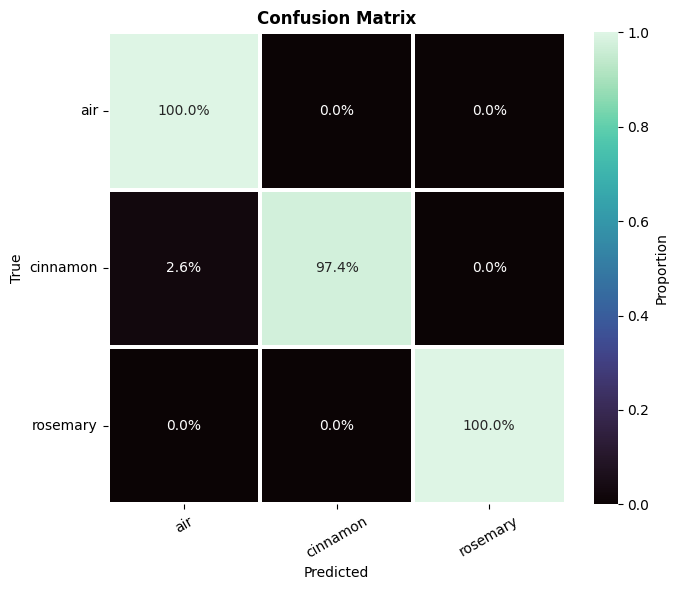

In [24]:
import seaborn as sns

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".1%",
    cmap="mako",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix", weight="bold")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
def evaluate_csv(file_path: str):
    import pandas as pd
    import numpy as np

    print(f"\nEvaluating: {file_path}")

    # Load
    df = pd.read_csv(file_path)

    # --- Match your preprocessing ---

    # Keep only stable rows
    df = df[df["label"].str.endswith("Stable")].copy()

    # Normalize labels
    df["label"] = df["label"].replace({"baselineStable": "air"})
    df["label"] = df["label"].str.replace("Stable", "", regex=False)

    # Fake session_id (single session)
    df["session_id"] = 0

    # Create ID (same as training)
    df["id"] = df.apply(
        lambda x: f"0_{int(x['sensor_index'])}_{int(x['fingerprint_index'])}",
        axis=1,
    )

    # --- Compute baseline (same logic) ---
    baseline = (
        df[df["label"] == "air"]
        .groupby(["session_id", "sensor_index", "position"])["gas_resistance"]
        .mean()
        .rename("R_base")
        .reset_index()
    )

    df = df.merge(
        baseline,
        on=["session_id", "sensor_index", "position"],
        how="left"
    )

    if df["R_base"].isna().any():
        raise ValueError("Missing air baseline in this CSV")

    # --- Feature engineering ---
    df["log_ratio"] = np.log(df["gas_resistance"] / df["R_base"])

    # Use TRAIN stats (must exist in memory!)
    for col in ["humidity"]:
        df[f"{col}_z"] = (
            df[col] - df["sensor_index"].map(train_data.groupby("sensor_index")[col].mean())
        ) / df["sensor_index"].map(train_data.groupby("sensor_index")[col].std())

    # Encode labels
    df["label_enc"] = label_encoder.transform(df["label"])

    # --- Keep valid sequences ---
    def keep_complete(df):
        valid_ids = (
            df.groupby("id")
              .size()
              .loc[lambda x: x == SEQ_LEN]
              .index
        )
        return df[df["id"].isin(valid_ids)]

    df = keep_complete(df)

    # --- Create sequences ---
    def create_sequences(df):
        X, y = [], []
        for _id, group in df.groupby("id"):
            group = group.sort_values("position")
            data = group[FEATURE_COLS].values

            if len(data) == SEQ_LEN:
                X.append(data)
                y.append(int(group["label_enc"].iloc[0]))

        return np.array(X, dtype=np.float32), np.array(y)

    X, y = create_sequences(df)

    if len(X) == 0:
        print("No valid sequences found.")
        return

    # --- Predict ---
    y_pred = np.argmax(model.predict(X), axis=1)

    acc = (y_pred == y).mean()
    print(f"Accuracy: {acc:.4f}")

    return acc

# evaluate_csv("../data/test/rosemary.csv")

In [16]:
for i, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {i}")

air -> 0
cinnamon -> 1
rosemary -> 2


In [17]:
import tensorflow as tf
import os

converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Removed converter.optimizations = [tf.lite.Optimize.DEFAULT] to disable quantization for debugging

converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Apply the suggested fix for LSTM models
#converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
#converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('model.tflite', 'wb') as f:
  f.write(tflite_model)

basic_model_size = os.path.getsize("model.tflite")
print("Model is %d bytes" % basic_model_size)


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpucnunc6j\assets


INFO:tensorflow:Assets written to: C:\Users\james\AppData\Local\Temp\tmpucnunc6j\assets


Saved artifact at 'C:\Users\james\AppData\Local\Temp\tmpucnunc6j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 2), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1984529595856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1985669813584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984529594128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984552501712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984552501904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984552503056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984552502672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1984552503248: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 10212 bytes


In [18]:
from ai_edge_litert.compiled_model import CompiledModel
import numpy as np # Import numpy as it's used in the loop

model_lite = CompiledModel.from_file("model.tflite")

signature_index = 0

input_buffers = model_lite.create_input_buffers(signature_index)
output_buffers = model_lite.create_output_buffers(signature_index)

n_correct = 0

for i in range(len(X_test)):
    input_data = np.float32(X_test[i])
    input_buffers[0].write(input_data)

    model_lite.run_by_index(signature_index, input_buffers, output_buffers)
    output_array = output_buffers[0].read(NUM_CLASSES, np.float32)

    pred_class = int(np.argmax(output_array))
    true_class = int(y_test[i])

    if pred_class == true_class:
        n_correct += 1

print("LiteRT accuracy:", n_correct / len(X_test))


LiteRT accuracy: 0.9938650306748467


In [19]:
with open("model.tflite", "rb") as f:
    data = f.read()

with open("model.h", "w") as f:
    f.write("const unsigned char model[] = {\n")
    
    for i, byte in enumerate(data):
        f.write(f"0x{byte:02x},")
        if (i + 1) % 12 == 0:
            f.write("\n")
    
    f.write("\n};\n")
    f.write(f"const unsigned int model_len = {len(data)};\n")

import os
print(f"Header file, model.h, is {os.path.getsize('model.h'):,} bytes.")

Header file, model.h, is 52,840 bytes.


In [20]:
env_stats = {}

for col in env_cols:
    means = train_data.groupby("sensor_index")[col].mean()
    stds  = train_data.groupby("sensor_index")[col].std()

    env_stats[col] = {
        "mean": means,
        "std": stds
    }

for col in env_cols:
    means = env_stats[col]["mean"]
    stds  = env_stats[col]["std"]

    print(f"\n// {col} normalization")

    # Mean array
    print(f"static const float {col.upper()}_MEAN[{len(means)}][1] = {{")
    for i, sensor in enumerate(means.index):
        val = means[sensor]
        comma = "," if i < len(means) - 1 else ""
        print(f"    {{{val:.8f}f}}{comma} // Index {sensor}")
    print("};\n")

    # Std array
    print(f"static const float {col.upper()}_STD[{len(stds)}][1] = {{")
    for i, sensor in enumerate(stds.index):
        val = stds[sensor]
        comma = "," if i < len(stds) - 1 else ""
        print(f"    {{{val:.8f}f}}{comma} // Index {sensor}")
    print("};")


// humidity normalization
static const float HUMIDITY_MEAN[8][1] = {
    {29.05021106f}, // Index 1
    {38.53102000f}, // Index 2
    {40.76500000f}, // Index 3
    {38.55140654f}, // Index 4
    {35.85886740f}, // Index 5
    {36.99456422f}, // Index 6
    {31.96686256f}, // Index 7
    {25.46282902f} // Index 8
};

static const float HUMIDITY_STD[8][1] = {
    {5.22754631f}, // Index 1
    {6.01597257f}, // Index 2
    {7.98125308f}, // Index 3
    {8.22437492f}, // Index 4
    {5.86649568f}, // Index 5
    {6.00023747f}, // Index 6
    {4.49351864f}, // Index 7
    {4.42566290f} // Index 8
};
